# Comprehensive Notes: Assumptions of Linear Regression

## Table of Contents
1. [Linearity](#1-linearity)
2. [Normality of Residuals](#2-normality-of-residuals)
3. [Homoscedasticity](#3-homoscedasticity)
4. [No Autocorrelation](#4-no-autocorrelation)
5. [No Multicollinearity](#5-no-multicollinearity)

---

## 1. Linearity

### 📚 Detailed Explanation

**What is Linearity?**

This is the foundational assumption of linear regression. The model assumes that the relationship between the independent variables (features or X) and the dependent variable (target or Y) is linear. This means that a unit change in X results in a constant change in Y, regardless of the value of X.

**Mathematical Representation:**
```
Y = β₀ + β₁X₁ + β₂X₂ + ... + βₙXₙ + ε
```

**What Happens When This Assumption is Violated?**
- **Bias in Parameter Estimates:** The estimated coefficients will not accurately reflect the true relationship.
- **Reduced Predictive Accuracy:** The model will underfit the data, missing important patterns.
- **Invalid Hypothesis Tests:** The p-values and confidence intervals become unreliable.

### 📊 Visual Diagram

```mermaid
graph TD
    A[Linearity Assumption] --> B{Check Methods}
    B --> C[Scatter Plots]
    B --> D[Residual Plots]
    B --> E[Polynomial Terms]
    
    C --> F[Linear Pattern?]
    D --> G[Random Scatter?]
    E --> H[Significant Improvement?]
    
    F -->|Yes| I[Assumption Met]
    F -->|No| J[Assumption Violated]
    G -->|Yes| I
    G -->|No| J
    H -->|No| I
    H -->|Yes| J
    
    J --> K[Solutions]
    K --> L[Transformations]
    K --> M[Polynomial Regression]
    K --> N[Piecewise Regression]
    K --> O[Non-parametric Methods]
```
#### **How to Check This Assumption**

In [29]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error

# ============================================================
# STEP 1: Generate a non-linear dataset with quadratic relationship
# ============================================================
# Set random seed for reproducibility
np.random.seed(42)

# Generate 100 random data points between 0 and 10
x = 10 * np.random.rand(100, 1)

# Create a quadratic relationship: y = x² + 5 + noise
# np.random.normal(0, 5, (100, 1)) adds Gaussian noise with mean=0, std=5
y = x**2 + 5 + np.random.normal(0, 5, (100, 1))

# Ensure all y values are non-negative (absolute value)
y = np.abs(y)


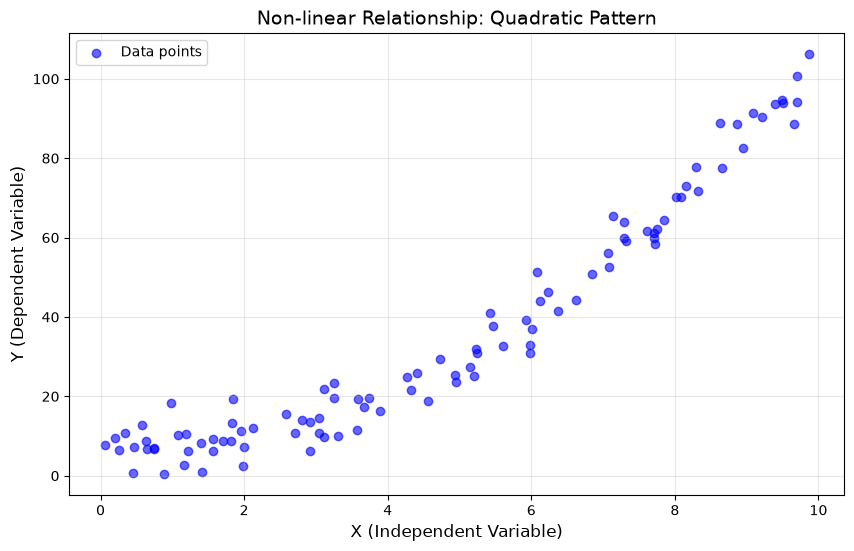

In [30]:
# ============================================================
# STEP 2: Visualize the non-linear relationship
# ============================================================
# Create scatter plot to visualize the data
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='blue', alpha=0.6, label='Data points')
plt.xlabel('X (Independent Variable)', fontsize=12)
plt.ylabel('Y (Dependent Variable)', fontsize=12)
plt.title('Non-linear Relationship: Quadratic Pattern', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================
# STEP 3: Check Linearity Assumption - Method 1: Scatter Plot
# ============================================================
# Visual inspection of scatter plot
# If points form a curved pattern instead of straight line,
# linearity assumption is violated

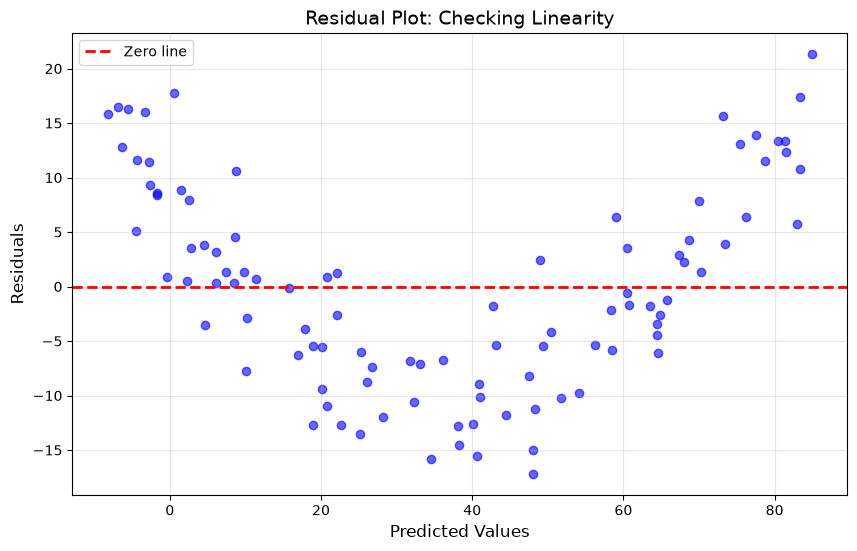

In [31]:
# ============================================================
# STEP 4: Check Linearity Assumption - Method 2: Residual Plot
# ============================================================
# Fit a simple linear regression model
linear_model = LinearRegression()
linear_model.fit(x, y)

# Get predictions
y_pred = linear_model.predict(x)

# Calculate residuals (difference between actual and predicted values)
residuals = y - y_pred

# Create residual plot
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero line')
plt.xlabel('Predicted Values', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residual Plot: Checking Linearity', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Interpretation:
# - If residuals show a pattern (curve, funnel shape), linearity is violated
# - If residuals are randomly scattered around zero, linearity holds


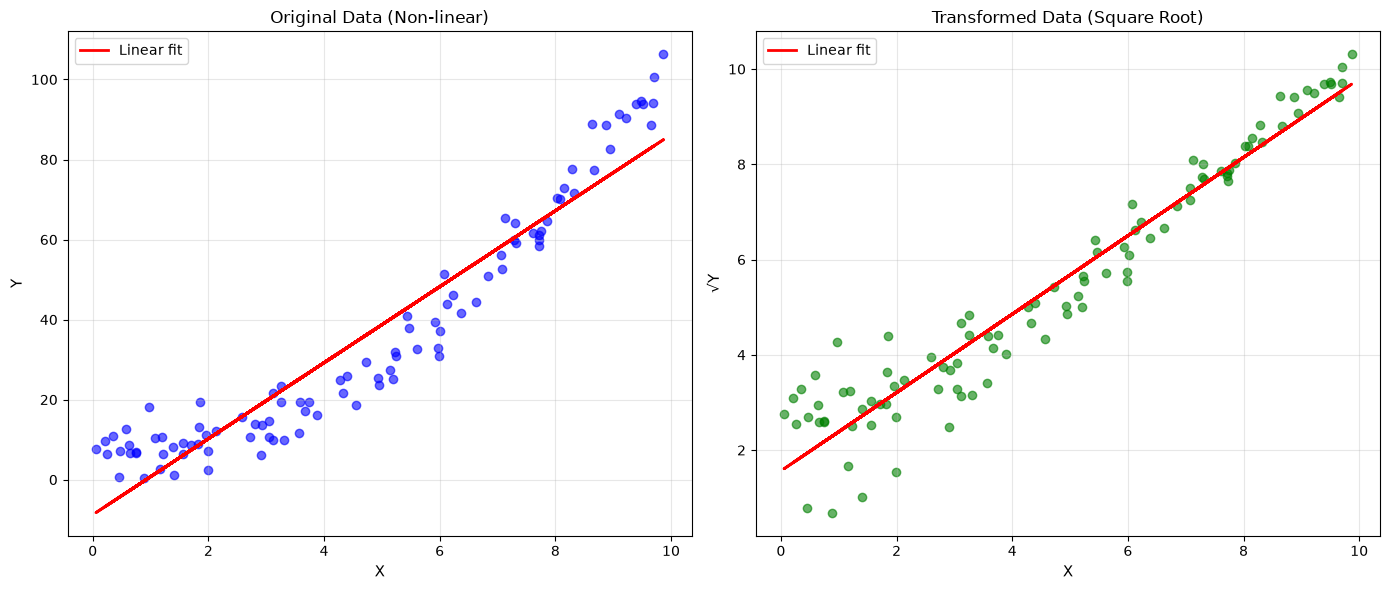

Original model R-squared: 0.9008
Transformed model R-squared: 0.9291


In [32]:
# ============================================================
# STEP 5: Solution 1 - Apply Transformation (Square Root)
# ============================================================
# Transform the dependent variable to make relationship more linear
y_sqrt = np.sqrt(y)

# Fit linear regression on transformed data
linear_model_transformed = LinearRegression()
linear_model_transformed.fit(x, y_sqrt)

# Get predictions for transformed model
y_pred_transformed = linear_model_transformed.predict(x)

# Visualize before and after transformation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Before transformation
ax1.scatter(x, y, color='blue', alpha=0.6)
ax1.plot(x, y_pred, color='red', linewidth=2, label='Linear fit')
ax1.set_title('Original Data (Non-linear)', fontsize=12)
ax1.set_xlabel('X', fontsize=11)
ax1.set_ylabel('Y', fontsize=11)
ax1.legend()
ax1.grid(True, alpha=0.3)

# After transformation
ax2.scatter(x, y_sqrt, color='green', alpha=0.6)
ax2.plot(x, y_pred_transformed, color='red', linewidth=2, label='Linear fit')
ax2.set_title('Transformed Data (Square Root)', fontsize=12)
ax2.set_xlabel('X', fontsize=11)
ax2.set_ylabel('√Y', fontsize=11)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate and compare R-squared values
r2_original = r2_score(y, y_pred)
r2_transformed = r2_score(y_sqrt, y_pred_transformed)

print(f"Original model R-squared: {r2_original:.4f}")
print(f"Transformed model R-squared: {r2_transformed:.4f}")

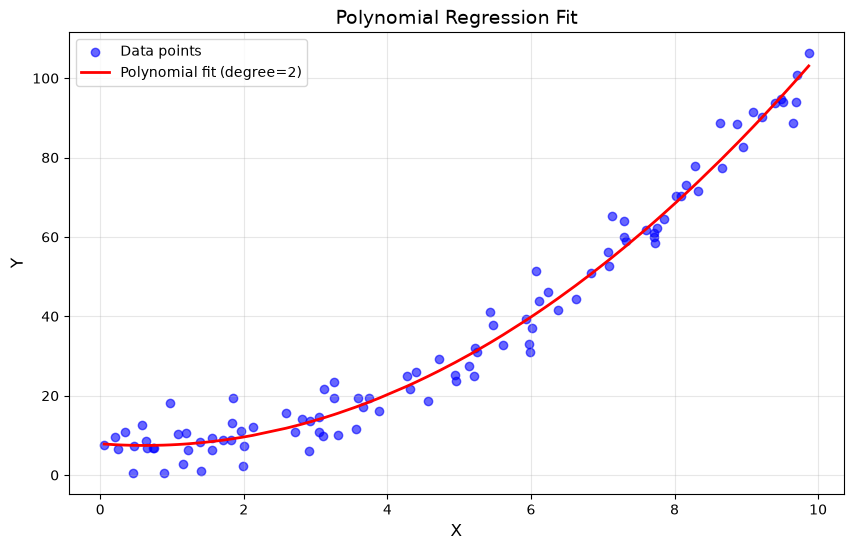


Polynomial Regression Results:
R-squared: 0.9782
Mean Squared Error: 19.0879


In [33]:
# ============================================================
# STEP 6: Solution 2 - Polynomial Regression
# ============================================================
# Add polynomial features to capture non-linear relationship
# degree=2 creates x and x² features
poly_features = PolynomialFeatures(degree=2, include_bias=False)
x_poly = poly_features.fit_transform(x)

# Fit polynomial regression model
poly_model = LinearRegression()
poly_model.fit(x_poly, y)

# Get predictions from polynomial model
y_pred_poly = poly_model.predict(x_poly)

# Visualize polynomial regression fit
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='blue', alpha=0.6, label='Data points')

# Sort x values for smooth curve plotting
x_sorted = np.sort(x, axis=0)
x_poly_sorted = poly_features.transform(x_sorted)
y_pred_poly_sorted = poly_model.predict(x_poly_sorted)

plt.plot(x_sorted, y_pred_poly_sorted, color='red', linewidth=2, label='Polynomial fit (degree=2)')
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.title('Polynomial Regression Fit', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calculate R-squared for polynomial model
r2_poly = r2_score(y, y_pred_poly)
mse_poly = mean_squared_error(y, y_pred_poly)

print(f"\nPolynomial Regression Results:")
print(f"R-squared: {r2_poly:.4f}")
print(f"Mean Squared Error: {mse_poly:.4f}")

In [43]:
# ============================================================
# STEP 7: Compare All Models
# ============================================================
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(f"{'Model':<30} {'R-squared':<15}")
print("-"*60)
print(f"{'Original Linear':<30} {r2_original:<15.4f}")
print(f"{'Transformed (Sqrt)':<30} {r2_transformed:<15.4f}")
print(f"{'Polynomial (degree=2)':<30} {r2_poly:<15.4f}")
print("="*60)


MODEL COMPARISON
Model                          R-squared      
------------------------------------------------------------
Original Linear                0.9008         
Transformed (Sqrt)             0.9291         
Polynomial (degree=2)          0.9782         


1.  **Scatter Plots:** The most straightforward check. If the points follow a roughly straight line (especially in simple linear regression), the assumption is likely met.
2.  **Residual Plots:** This is the most powerful diagnostic for linearity. Plot the residuals (actual - predicted) against the predicted values. If the linearity assumption holds, the residuals should be randomly scattered around the zero line with no clear pattern. A U-shape or an inverted U-shape indicates a non-linear relationship.
3.  **Adding Polynomial Terms:** If a polynomial term significantly improves the model's fit, it suggests the relationship is non-linear.

#### **What to Do When the Assumption Fails?**
- **Transformations:** Apply transformations like `log`, `sqrt`, or inverse to the dependent and/or independent variables to linearize the relationship.
- **Polynomial Regression:** Add polynomial terms (`x^2`, `x^3`) to the model to capture the curve.
    - **Piecewise Regression:** Split the data at certain points (knots) and fit separate linear models to each segment.
    - **Non-Parametric Methods:** Use methods like Generalized Additive Models (GAMs) or splines that don't assume a specific relationship form.

#### **Key Takeaways**
1. Scatter plots help visualize non-linear patterns
2. Residual plots reveal systematic patterns when linearity is violated
3. Transformations (sqrt, log, inverse) can linearize relationships
4. Polynomial regression adds flexibility to capture curvature
5. Always compare model performance using metrics like R-squared


```mermaid
sequenceDiagram
    participant Data as Original Data
    participant Check as Check Linearity
    participant Transform as Apply Transformation
    participant Poly as Polynomial Regression
    participant Model as Final Model
    
    Data->>Check: Scatter Plot & Residual Plot
    Check->>Check: Detect Pattern?
    alt Pattern Detected (Non-linear)
        Check->>Transform: Try sqrt/log transform
        Transform->>Model: Check improved linearity
        alt Still Non-linear
            Check->>Poly: Add polynomial terms
            Poly->>Model: degree=2, 3, etc.
        end
    else No Pattern (Linear)
        Check->>Model: Use linear model
    end
    Model->>Model: Validate assumptions
```
---

## 2. Normality of Residuals

The assumption is about the error terms, not the variables themselves.

**What is Normality of Residuals?**

The errors (residuals) of the model are assumed to be normally distributed with a mean of zero. This is essential for the validity of hypothesis tests and confidence intervals, especially in small samples.

**Why Important?**
- T-tests and F-tests assume normality
- Confidence intervals rely on normal distribution
- Large samples can relax this assumption (Central Limit Theorem)

 **What Happens When This Assumption is Violated?**
- **Inaccurate Hypothesis Tests:** The p-values for t-tests and F-tests become unreliable.
- **Invalid Confidence Intervals:** Confidence intervals for coefficients may not reflect the true uncertainty.
- **Model Performance:** Severe non-normality can indicate that the model is mis-specified or that outliers are present.



### 📊 Visual Diagram

```mermaid
graph LR
    A[Fit Linear Model] --> B[Calculate Residuals]
    B --> C{Check Normality}
    
    C --> D[Histogram]
    C --> E[Q-Q Plot]
    C --> F[Statistical Tests]
    
    D --> G[Bell-shaped?]
    E --> H[Straight line?]
    F --> I[p-value > 0.05?]
    
    G -->|Yes| J[Normal]
    G -->|No| K[Not Normal]
    H -->|Yes| J
    H -->|No| K
    I -->|Yes| J
    I -->|No| K
    
    K --> L[Solutions]
    L --> M[Transform Y]
    L --> N[Robust Regression]
    L --> O[Bootstrapping]
    L --> P[Non-parametric]
```
 **How to Check This Assumption**
1.  **Histogram of Residuals:** Plot the residuals as a histogram. If it resembles a bell-shaped curve, the assumption is likely met.
2.  **Q-Q Plot (Quantile-Quantile Plot):** This is the most robust visual check. It plots the quantiles of your residuals against the quantiles of a theoretical normal distribution. If the points fall close to the diagonal reference line, the residuals are normally distributed.
3.  **Statistical Tests:** Tests like the **Omnibus Test** (D'Agostino-Pearson), **Jarque-Bera Test**, or **Shapiro-Wilk Test** can formally test for normality. A low p-value indicates a violation of the assumption.

**What to Do When the Assumption Fails?**
- **Transformations:** Transform the dependent variable (e.g., using `log` or `sqrt`) to make the residuals more normally distributed.
- **Robust Regression:** Use methods like M-estimation that are less sensitive to violations of normality.
- **Non-Parametric Methods:** Use methods that do not require the normality assumption.
- **Use Bootstrapping:** Bootstrap-based inference is robust to non-normal residuals.


In [44]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from scipy.stats import shapiro, jarque_bera

# ============================================================
# STEP 1: Generate sample data
# ============================================================
np.random.seed(42)
n_samples = 100

# Generate X values
x = np.random.rand(n_samples, 1) * 10

# Generate y with normal errors (good case)
y_normal = 2 * x.flatten() + 5 + np.random.normal(0, 2, n_samples)

# Generate y with non-normal errors (bad case - skewed)
y_skewed = 2 * x.flatten() + 5 + np.random.exponential(2, n_samples)


In [45]:
# ============================================================
# STEP 2: Fit linear regression models
# ============================================================
# Model 1: Normal residuals
model_normal = LinearRegression()
model_normal.fit(x, y_normal)
y_pred_normal = model_normal.predict(x)
residuals_normal = y_normal - y_pred_normal

# Model 2: Non-normal residuals
model_skewed = LinearRegression()
model_skewed.fit(x, y_skewed)
y_pred_skewed = model_skewed.predict(x)
residuals_skewed = y_skewed - y_pred_skewed


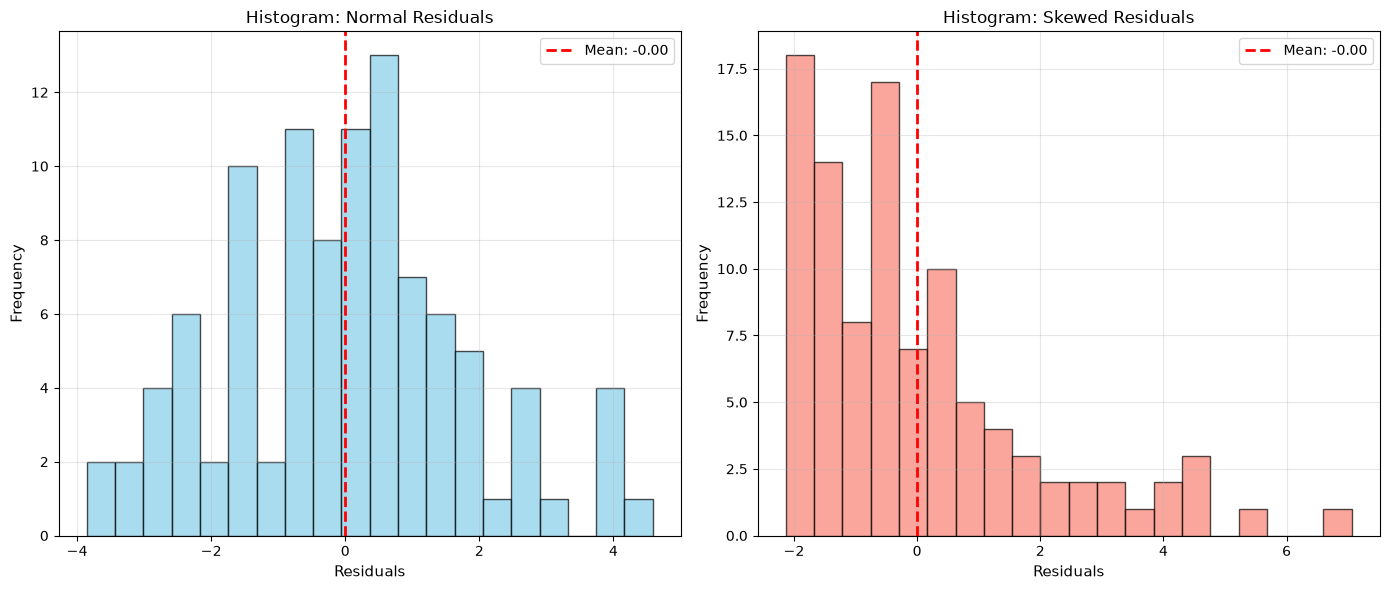

In [ ]:
# ============================================================
# STEP 3: Check Normality - Method 1: Histogram
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Histogram for normal residuals
ax1.hist(residuals_normal, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(residuals_normal.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {residuals_normal.mean():.2f}')
ax1.set_title('Histogram: Normal Residuals', fontsize=12)
ax1.set_xlabel('Residuals', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Histogram for skewed residuals
ax2.hist(residuals_skewed, bins=20, color='salmon', edgecolor='black', alpha=0.7)
ax2.axvline(residuals_skewed.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {residuals_skewed.mean():.2f}')
ax2.set_title('Histogram: Skewed Residuals', fontsize=12)
ax2.set_xlabel('Residuals', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

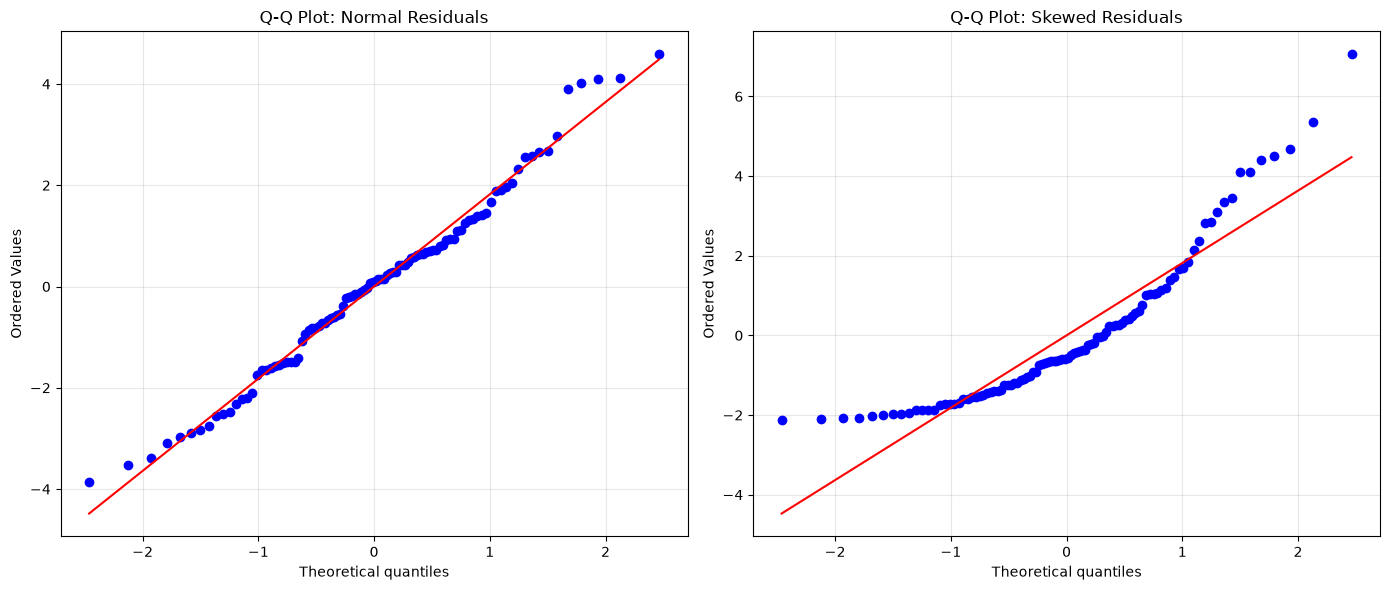

In [ ]:
# ============================================================
# STEP 4: Check Normality - Method 2: Q-Q Plot
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Q-Q plot for normal residuals
stats.probplot(residuals_normal, dist="norm", plot=ax1)
ax1.set_title('Q-Q Plot: Normal Residuals', fontsize=12)
ax1.grid(True, alpha=0.3)

# Q-Q plot for skewed residuals
stats.probplot(residuals_skewed, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot: Skewed Residuals', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretation:
# - Points following the diagonal line = normal distribution
# - Points deviating from the line = non-normal distribution

In [48]:
# ============================================================
# STEP 5: Check Normality - Method 3: Statistical Tests
# ============================================================
print("="*70)
print("NORMALITY TESTS FOR RESIDUALS")
print("="*70)

# Shapiro-Wilk Test
# Null hypothesis: Data is normally distributed
# H0: Residuals follow a Normal Distribution.
# H1:Residuals do NOT follow a Normal Distribution.

shapiro_stat_normal, shapiro_pval_normal = shapiro(residuals_normal)
shapiro_stat_skewed, shapiro_pval_skewed = shapiro(residuals_skewed)

print(f"\nShapiro-Wilk Test:")
print(f"  Normal Residuals:   Statistic = {shapiro_stat_normal:.4f}, p-value = {shapiro_pval_normal:.4f}")
print(f"  Skewed Residuals:   Statistic = {shapiro_stat_skewed:.4f}, p-value = {shapiro_pval_skewed:.4f}")

# Jarque-Bera Test
# Tests if skewness and kurtosis match normal distribution

jb_result_normal = jarque_bera(residuals_normal)
# jb_stat_normal, jb_pval_normal, _, _ = jarque_bera(residuals_normal)

jb_result_skewed = jarque_bera(residuals_skewed)
# jb_stat_skewed, jb_pval_skewed, _, _ = jarque_bera(residuals_skewed)

print(f"\nJarque-Bera Test:")
print(f"  Normal Residuals:   Statistic = {jb_result_normal.statistic:.4f}, p-value = {jb_result_normal.pvalue:.4f}")
print(f"  Skewed Residuals:   Statistic = {jb_result_skewed.statistic:.4f}, p-value = {jb_result_skewed.pvalue:.4f}")

# Interpretation guide
print(f"\n{'='*70}")
print("INTERPRETATION:")
print(f"{'='*70}")
print("If p-value < 0.05: Reject null hypothesis (residuals NOT normal)")
print("If p-value >= 0.05: Fail to reject null hypothesis (residuals normal)")
print(f"{'='*70}")


NORMALITY TESTS FOR RESIDUALS

Shapiro-Wilk Test:
  Normal Residuals:   Statistic = 0.9846, p-value = 0.2984
  Skewed Residuals:   Statistic = 0.8672, p-value = 0.0000

Jarque-Bera Test:
  Normal Residuals:   Statistic = 0.8079, p-value = 0.6677
  Skewed Residuals:   Statistic = 40.3525, p-value = 0.0000

INTERPRETATION:
If p-value < 0.05: Reject null hypothesis (residuals NOT normal)
If p-value >= 0.05: Fail to reject null hypothesis (residuals normal)



After Log Transformation:
  Shapiro-Wilk p-value: 0.0567
  Residuals are now normal!


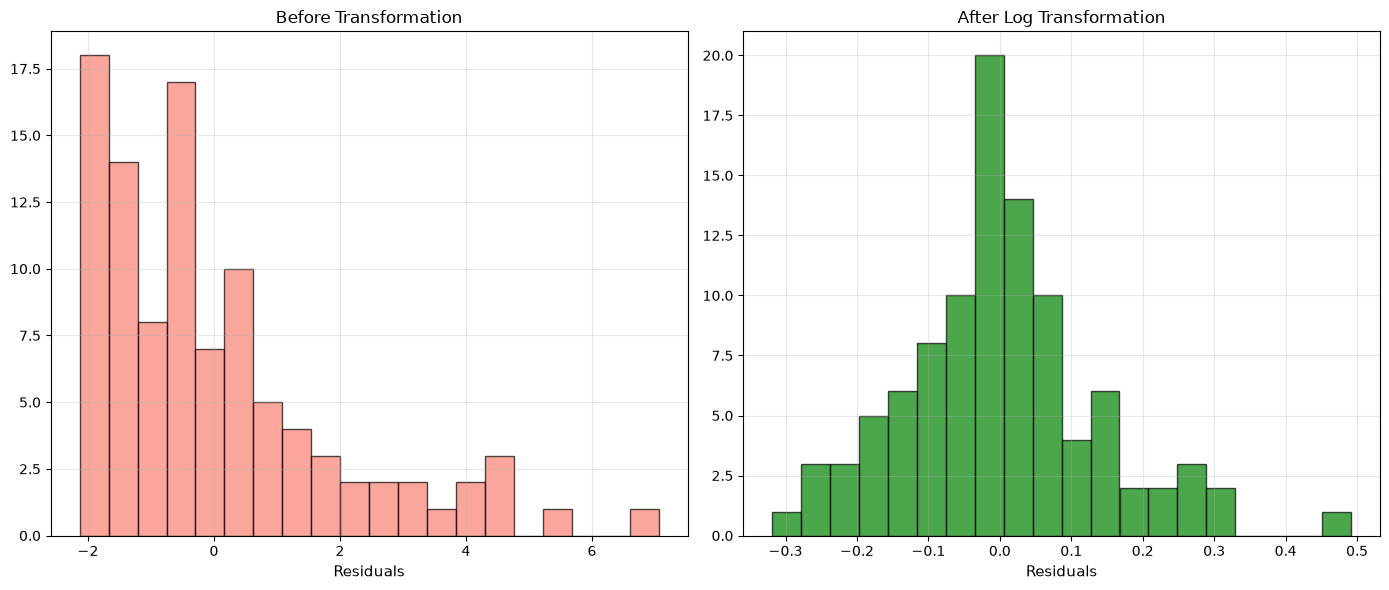

In [49]:
# ============================================================
# STEP 6: Solution - Transform Dependent Variable
# ============================================================
# Apply log transformation to fix non-normality
y_skewed_transformed = np.log(y_skewed + 1)  # Add 1 to avoid log(0)

# Refit model with transformed data
model_transformed = LinearRegression()
model_transformed.fit(x, y_skewed_transformed)
y_pred_transformed = model_transformed.predict(x)
residuals_transformed = y_skewed_transformed - y_pred_transformed

# Test normality of transformed residuals
shapiro_stat_trans, shapiro_pval_trans = shapiro(residuals_transformed)

print(f"\nAfter Log Transformation:")
print(f"  Shapiro-Wilk p-value: {shapiro_pval_trans:.4f}")
print(f"  {'Residuals are now normal!' if shapiro_pval_trans > 0.05 else 'Still not normal'}")

# Visualize improvement
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Before transformation
ax1.hist(residuals_skewed, bins=20, color='salmon', alpha=0.7, edgecolor='black')
ax1.set_title('Before Transformation', fontsize=12)
ax1.set_xlabel('Residuals', fontsize=11)
ax1.grid(True, alpha=0.3)

# After transformation
ax2.hist(residuals_transformed, bins=20, color='green', alpha=0.7, edgecolor='black')
ax2.set_title('After Log Transformation', fontsize=12)
ax2.set_xlabel('Residuals', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Key Takeaways:**
1. Use histogram for visual inspection of residual distribution
2. Q-Q plot compares quantiles to normal distribution
3. Statistical tests (Shapiro-Wilk, Jarque-Bera) provide objective measures
4. Transformations (log, sqrt, Box-Cox) can fix non-normality
5. Large sample sizes (>30) can relax normality assumption (CLT)


```mermaid
graph TB
    Start[Fit Linear Model] --> Calc[Calculate Residuals]
    Calc --> Test1{Histogram}
    Calc --> Test2{Q-Q Plot}
    Calc --> Test3{Statistical Test}
    
    Test1 -->|Bell-shaped| Normal[Normal Distribution]
    Test1 -->|Skewed| NotNormal[Non-Normal]
    
    Test2 -->|Straight line| Normal
    Test2 -->|Curved| NotNormal
    
    Test3 -->|p > 0.05| Normal
    Test3 -->|p < 0.05| NotNormal
    
    NotNormal --> Transform[Apply Transformation]
    Transform -->|Log/Sqrt/Box-Cox| Refit[Refit Model]
    Refit --> Retest{Re-test Normality}
    Retest -->|Still not normal| Robust[Use Robust Regression]
    Retest -->|Normal| Done[Assumption Met]
    
    Normal --> Done
```

---

## 3. Homoscedasticity

This assumption concerns the spread of the residuals.

**What is Homoscedasticity?**

Homoscedasticity means that the variance of residuals is constant across all levels of the independent variables. When variance changes systematically, it's called heteroscedasticity.

**Visual Pattern:**
- **Homoscedastic**: Residuals form a random horizontal band
- **Heteroscedastic**: Residuals form a funnel or cone shape

**What Happens When This Assumption is Violated?**
- **Inefficient Estimates:** The coefficients are still unbiased but are no longer the most efficient (i.e., the best linear unbiased estimators, BLUE).
- **Inaccurate Hypothesis Tests:** Standard errors are biased, leading to incorrect t-tests and F-tests.
- **Invalid Confidence Intervals:** Confidence intervals are unreliable.
- Hypothesis tests become unreliable

### 📊 Visual Diagram

```mermaid
graph TD
    A[Fit OLS Model] --> B[Plot Residuals vs Fitted]
    B --> C{Check Pattern}
    
    C -->|Random scatter| D[Homoscedastic ✓]
    C -->|Funnel shape| E[Heteroscedastic ✗]
    C -->|Curve pattern| E
    
    E --> F[Breusch-Pagan Test]
    F --> G{p-value < 0.05?}
    
    G -->|Yes| H[Heteroscedasticity Confirmed]
    G -->|No| D
    
    H --> I[Solutions]
    I --> J[Transform Variables]
    I --> K[Weighted Least Squares]
    I --> L[Robust Standard Errors]
```
**How to Check This Assumption**
1.  **Residual Plot:** This is the primary diagnostic tool. Plot the residuals against the predicted values. If there's a fanning-out (increasing variance) or fanning-in (decreasing variance) pattern, heteroscedasticity is present.
2.  **Breusch-Pagan Test:** A formal statistical test. The null hypothesis is that the error variances are constant.

**What to Do When the Assumption Fails?**
- **Transformations:** Transform the dependent variable (e.g., `log(y)`) to stabilize variance.
- **Weighted Least Squares (WLS):** Assign different weights to observations based on their variance. For example, if variance increases with `x`, weight each observation by `1/x`.
- **Robust Standard Errors:** Use the "HC" (Heteroscedasticity-Consistent) versions of standard errors (e.g., `HC0`, `HC1`). In statsmodels, you can specify `cov_type='HC1'` in the `fit()` method.
- **Heteroscedasticity-Consistent Standard Errors (HAC):** For time series data, use Newey-West standard errors to account for autocorrelation and heteroscedasticity.

In [50]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.linear_model import LinearRegression

# ============================================================
# STEP 1: Generate data with heteroscedasticity
# ============================================================
np.random.seed(42)
n_samples = 100

# Generate X values
x = np.linspace(0, 10, n_samples)

# Generate y with heteroscedastic errors
# Variance increases with x (heteroscedasticity)
# (0.5 * x) ** 2 creates increasing variance
y = 2 * x + 1 + np.random.normal(0, (0.5 * x) ** 2, n_samples)

# Reshape for sklearn
x = x.reshape(-1, 1)

In [51]:
# ============================================================
# STEP 2: Fit OLS (Ordinary Least Squares) model
# ============================================================
# Add constant term for intercept
x_with_constant = sm.add_constant(x)

# Fit OLS model using statsmodels
model_ols = sm.OLS(y, x_with_constant).fit()

# Get predictions and residuals
y_pred_ols = model_ols.predict(x_with_constant)
residuals_ols = model_ols.resid

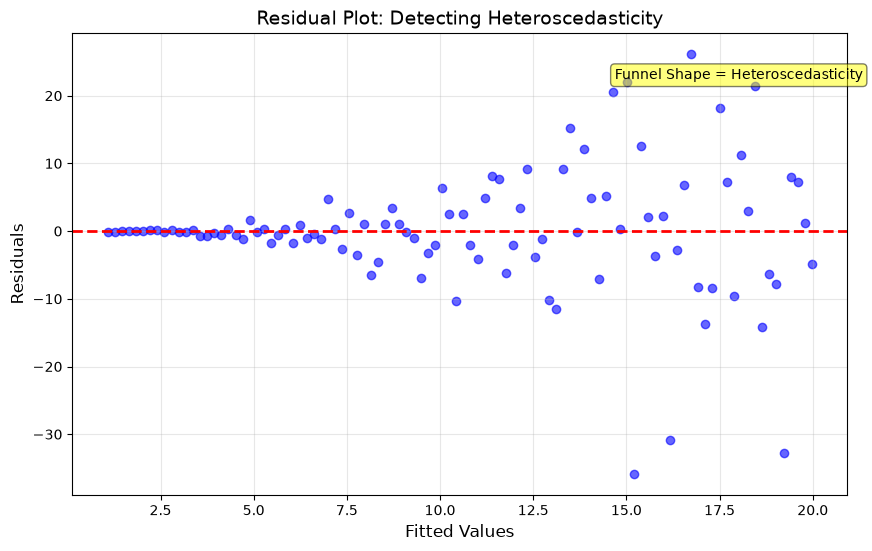

In [52]:
# ============================================================
# STEP 3: Visualize Heteroscedasticity
# ============================================================
# Create residual plot
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_ols, residuals_ols, alpha=0.6, color='blue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Fitted Values', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residual Plot: Detecting Heteroscedasticity', fontsize=14)
plt.grid(True, alpha=0.3)

# Add annotation
plt.annotate('Funnel Shape = Heteroscedasticity', 
             xy=(0.7, 0.9), xycoords='axes fraction',
             fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.5))

plt.show()

# Interpretation:
# - Funnel shape indicates heteroscedasticity
# - Variance increases as fitted values increase


In [53]:
# ============================================================
# STEP 4: Breusch-Pagan Test for Heteroscedasticity
# ============================================================
# The Breusch-Pagan test formally tests for heteroscedasticity
# Null hypothesis: Homoscedasticity (constant variance)
# Alternative hypothesis: Heteroscedasticity (non-constant variance)

# Perform Breusch-Pagan test
# het_breuschpagan returns: [LM Statistic, LM p-value, F-statistic, F p-value]
bp_test = het_breuschpagan(residuals_ols, x_with_constant)

# Extract test results
lm_statistic = bp_test[0]
lm_p_value = bp_test[1]
f_statistic = bp_test[2]
f_p_value = bp_test[3]

# Display results
print("="*70)
print("BREUSCH-PAGAN TEST FOR HETEROSCEDASTICITY")
print("="*70)
print(f"\nTest Statistics:")
print(f"  LM Statistic:    {lm_statistic:.4f}")
print(f"  LM p-value:      {lm_p_value:.4f}")
print(f"  F-statistic:     {f_statistic:.4f}")
print(f"  F p-value:       {f_p_value:.4f}")

print(f"\n{'='*70}")
print("INTERPRETATION:")
print(f"{'='*70}")
if lm_p_value < 0.05:
    print("✓ Heteroscedasticity DETECTED (p-value < 0.05)")
    print("  → Reject null hypothesis of homoscedasticity")
else:
    print("✗ No evidence of heteroscedasticity (p-value >= 0.05)")
    print("  → Fail to reject null hypothesis")
print(f"{'='*70}")


BREUSCH-PAGAN TEST FOR HETEROSCEDASTICITY

Test Statistics:
  LM Statistic:    15.6648
  LM p-value:      0.0001
  F-statistic:     18.2029
  F p-value:       0.0000

INTERPRETATION:
✓ Heteroscedasticity DETECTED (p-value < 0.05)
  → Reject null hypothesis of homoscedasticity



After Log Transformation:
  Breusch-Pagan p-value: 0.0254
  Still heteroscedastic


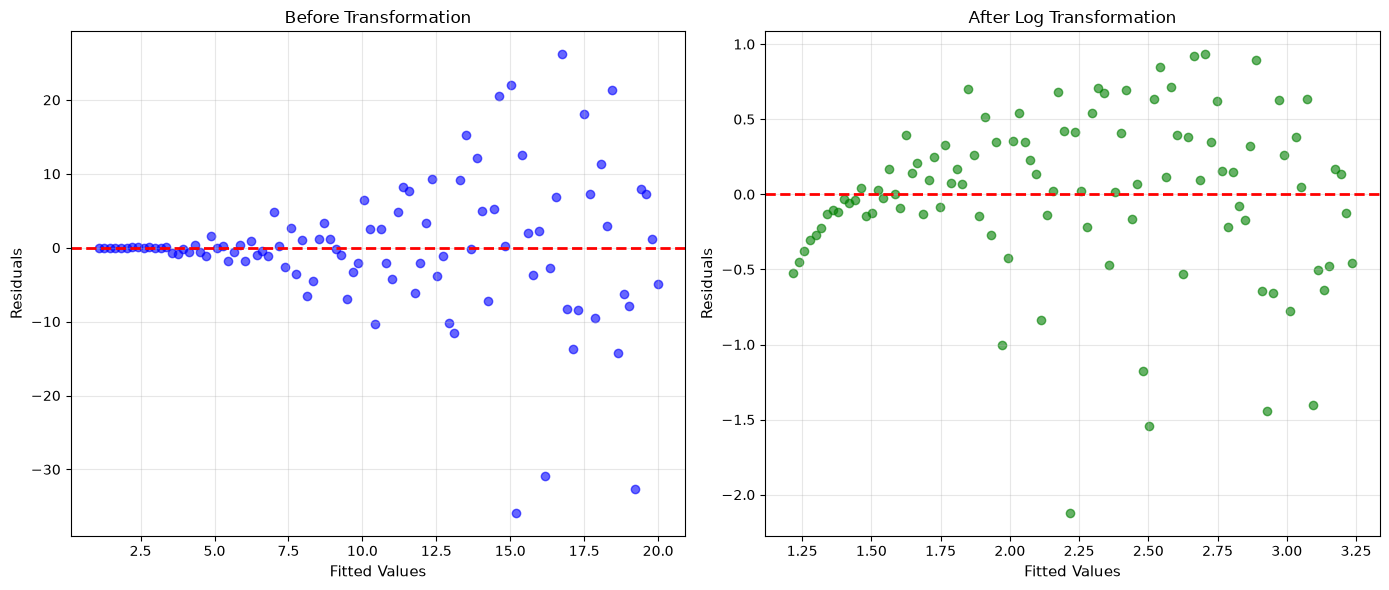

In [54]:
# ============================================================
# STEP 5: Solution 1 - Transform Dependent Variable
# ============================================================
# Apply log transformation to stabilize variance
y_transformed = np.log(np.abs(y) + 1)  # Add 1 to avoid log(0)

# Refit model with transformed data
model_transformed = sm.OLS(y_transformed, x_with_constant).fit()
residuals_transformed = model_transformed.resid
y_pred_transformed = model_transformed.predict(x_with_constant)

# Test for heteroscedasticity in transformed model
bp_test_transformed = het_breuschpagan(residuals_transformed, x_with_constant)
lm_pval_transformed = bp_test_transformed[1]

print(f"\nAfter Log Transformation:")
print(f"  Breusch-Pagan p-value: {lm_pval_transformed:.4f}")
print(f"  {'Heteroscedasticity FIXED!' if lm_pval_transformed > 0.05 else 'Still heteroscedastic'}")

# Visualize improvement
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Before transformation
ax1.scatter(y_pred_ols, residuals_ols, alpha=0.6, color='blue')
ax1.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax1.set_title('Before Transformation', fontsize=12)
ax1.set_xlabel('Fitted Values', fontsize=11)
ax1.set_ylabel('Residuals', fontsize=11)
ax1.grid(True, alpha=0.3)

# After transformation
ax2.scatter(y_pred_transformed, residuals_transformed, alpha=0.6, color='green')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax2.set_title('After Log Transformation', fontsize=12)
ax2.set_xlabel('Fitted Values', fontsize=11)
ax2.set_ylabel('Residuals', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


After Weighted Least Squares:
  Breusch-Pagan p-value: 0.0001
  Still heteroscedastic

MODEL COMPARISON: OLS vs WLS

Metric                    OLS                  WLS                 
----------------------------------------------------------------------
R-squared                 0.2641               0.9943              
Adj. R-squared            0.2566               0.9942              
AIC                       731.65               409.77              
BIC                       736.86               414.98              


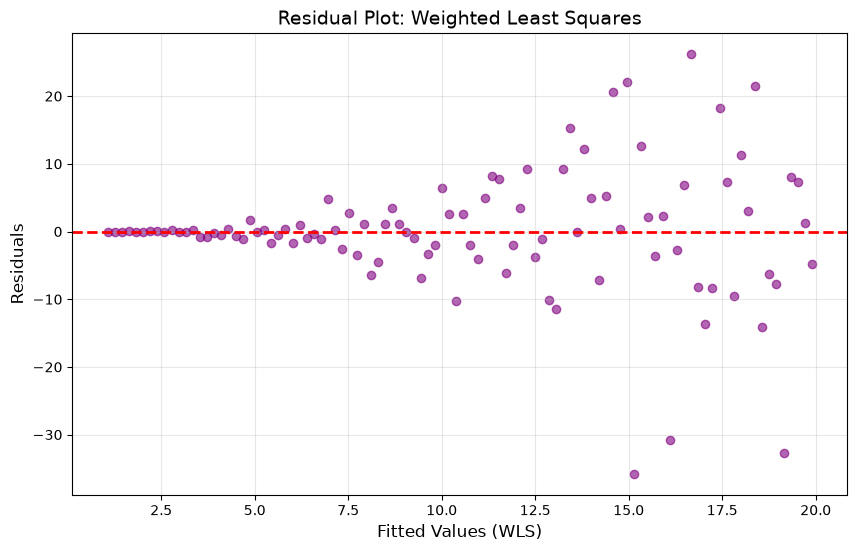

In [55]:
# ============================================================
# STEP 6: Solution 2 - Weighted Least Squares (WLS)
# ============================================================
# WLS assigns weights to observations based on residual variance
# Observations with higher variance get lower weights

# Calculate weights: inverse of squared residuals
# Add small constant to avoid division by zero
weights = 1 / (residuals_ols**2 + 1e-6)

# Fit WLS model
model_wls = sm.WLS(y, x_with_constant, weights=weights).fit()

# Get WLS predictions and residuals
y_pred_wls = model_wls.predict(x_with_constant)
residuals_wls = model_wls.resid

# Test for heteroscedasticity in WLS model
bp_test_wls = het_breuschpagan(residuals_wls, x_with_constant)
lm_pval_wls = bp_test_wls[1]

print(f"\nAfter Weighted Least Squares:")
print(f"  Breusch-Pagan p-value: {lm_pval_wls:.4f}")
print(f"  {'Heteroscedasticity FIXED!' if lm_pval_wls > 0.05 else 'Still heteroscedastic'}")

# Display model summaries
print("\n" + "="*70)
print("MODEL COMPARISON: OLS vs WLS")
print("="*70)
print(f"\n{'Metric':<25} {'OLS':<20} {'WLS':<20}")
print("-"*70)
print(f"{'R-squared':<25} {model_ols.rsquared:<20.4f} {model_wls.rsquared:<20.4f}")
print(f"{'Adj. R-squared':<25} {model_ols.rsquared_adj:<20.4f} {model_wls.rsquared_adj:<20.4f}")
print(f"{'AIC':<25} {model_ols.aic:<20.2f} {model_wls.aic:<20.2f}")
print(f"{'BIC':<25} {model_ols.bic:<20.2f} {model_wls.bic:<20.2f}")
print("="*70)

# Visualize WLS results
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_wls, residuals_wls, alpha=0.6, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Fitted Values (WLS)', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residual Plot: Weighted Least Squares', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

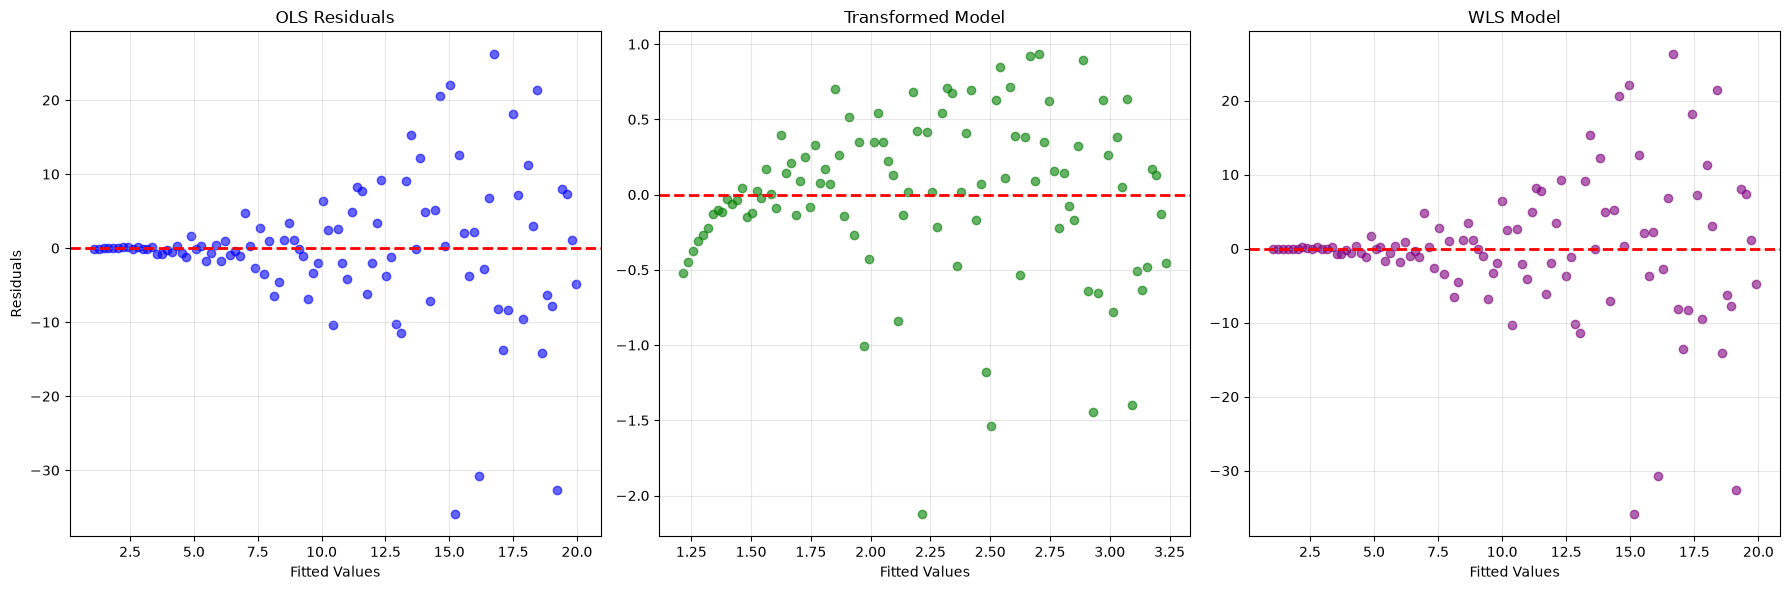

In [56]:
# ============================================================
# STEP 7: Compare Residual Patterns
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# OLS residuals
axes[0].scatter(y_pred_ols, residuals_ols, alpha=0.6, color='blue')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('OLS Residuals', fontsize=12)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].grid(True, alpha=0.3)

# Transformed model residuals
axes[1].scatter(y_pred_transformed, residuals_transformed, alpha=0.6, color='green')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Transformed Model', fontsize=12)
axes[1].set_xlabel('Fitted Values')
axes[1].grid(True, alpha=0.3)

# WLS residuals
axes[2].scatter(y_pred_wls, residuals_wls, alpha=0.6, color='purple')
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[2].set_title('WLS Model', fontsize=12)
axes[2].set_xlabel('Fitted Values')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Key Takeaways:**
1. Residual plots reveal heteroscedasticity (funnel shape)
2. Breusch-Pagan test formally tests for heteroscedasticity
3. Transformations (log, sqrt) can stabilize variance
4. WLS assigns weights to account for varying variance
5. Robust standard errors provide valid inference under heteroscedasticity


```mermaid
sequenceDiagram
    participant Data as Data with Heteroscedasticity
    participant OLS as OLS Model
    participant Test as Breusch-Pagan Test
    participant Transform as Transformation
    participant WLS as Weighted Least Squares
    
    Data->>OLS: Fit OLS Model
    OLS->>Test: Calculate Residuals
    Test->>Test: Perform BP Test
    Test->>Test: p-value < 0.05?
    
    alt Heteroscedasticity Detected
        Test->>Transform: Apply Log/Sqrt Transform
        Transform->>Test: Re-test
        alt Still Heteroscedastic
            Test->>WLS: Apply WLS
            WLS->>WLS: Calculate Weights
            WLS->>WLS: Refit Model
        end
    else Homoscedastic
        Test->>OLS: Assumption Met
    end
```

---

## 4. No Autocorrelation 

This assumption is especially crucial for time-series data.

**What is Autocorrelation?**
Autocorrelation (or serial correlation) occurs when residuals are correlated with each other, typically in time series data. This violates the assumption that errors are independent.

**Types:**
- **Positive autocorrelation**: Positive residuals tend to follow positive residuals
- **Negative autocorrelation**: Positive residuals tend to follow negative residuals


**What Happens When This Assumption is Violated?**
- **Inefficient Estimates:** While the coefficients remain unbiased, they are not BLUE, and the standard errors are likely underestimated.
- **Inaccurate Hypothesis Tests:** T-tests and F-tests will be overly optimistic, leading to false positives (Type I errors).
- **Invalid Confidence Intervals:** Confidence intervals will be too narrow.
- Standard errors are underestimated
- t-statistics are inflated
- Model appears more significant than it actually is

**How to Check This Assumption**
1.  **Durbin-Watson Test:** This is the most common test for first-order autocorrelation. The test statistic ranges from 0 to 4. A value of 2 suggests no autocorrelation, values <2 indicate positive autocorrelation, and values >2 suggest negative autocorrelation.
2.  **Residual Plot (Time Series):** Plot residuals in the order they were collected (usually time). If you see a pattern (e.g., runs of positive and negative residuals), it's a sign of autocorrelation.

**What to Do When the Assumption Fails?**
- **Add Lagged Variables:** Include a lagged version of the dependent variable as a predictor (e.g., `y(t-1)`).
- **Differencing:** Calculate the difference between consecutive observations (`y(t) - y(t-1)`) and model that.
- **Generalized Least Squares (GLS):** Use a model that explicitly accounts for the autocorrelation structure (e.g., `AR(1)` structure).
- **Time Series Models:** Use specialized models like ARIMA, which are designed for autocorrelated data.
- **Robust Standard Errors:** Use Newey-West standard errors, which are robust to autocorrelation and heteroscedasticity.


### 📊 Visual Diagram

```mermaid
graph TD
    A[Time Series Data] --> B[Fit Regression Model]
    B --> C[Plot Residuals vs Time]
    C --> D{Check Pattern}
    
    D -->|Random| E[No Autocorrelation ✓]
    D -->|Systematic pattern| F[Autocorrelation ✗]
    
    F --> G[Durbin-Watson Test]
    G --> H{DW Statistic}
    
    H -->|≈ 2| E
    H -->|< 2| I[Positive Autocorrelation]
    H -->|> 2| J[Negative Autocorrelation]
    
    I --> K[Solutions]
    J --> K
    
    K --> L[Add Lagged Variables]
    K --> M[Differencing]
    K --> N[GLS/ARIMA Models]
    K --> O[Robust SE Newey-West]
```



In [57]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from sklearn.linear_model import LinearRegression

# ============================================================
# STEP 1: Generate time series data with autocorrelation
# ============================================================
np.random.seed(42)
n_obs = 100

# Create time index
time = np.arange(1, n_obs + 1)

# Generate X variable
x = np.random.rand(n_obs) * 10

# Generate y with autocorrelated errors
# Create autocorrelated errors using AR(1) process
# ε_t = ρ * ε_(t-1) + u_t, where ρ = 0.7 (autocorrelation parameter)
rho = 0.7  # Autocorrelation coefficient
errors = np.zeros(n_obs)
errors[0] = np.random.normal(0, 1)

for t in range(1, n_obs):
    errors[t] = rho * errors[t-1] + np.random.normal(0, 1)

# Create y variable
y = 2 * x + 5 + errors

# Create DataFrame for time series analysis
df = pd.DataFrame({
    'time': time,
    'x': x,
    'y': y,
    'errors': errors
})

In [58]:
# ============================================================
# STEP 2: Fit OLS model
# ============================================================
# Add constant term
x_with_const = sm.add_constant(df['x'])

# Fit OLS model
model = sm.OLS(df['y'], x_with_const).fit()

# Get residuals
residuals = model.resid

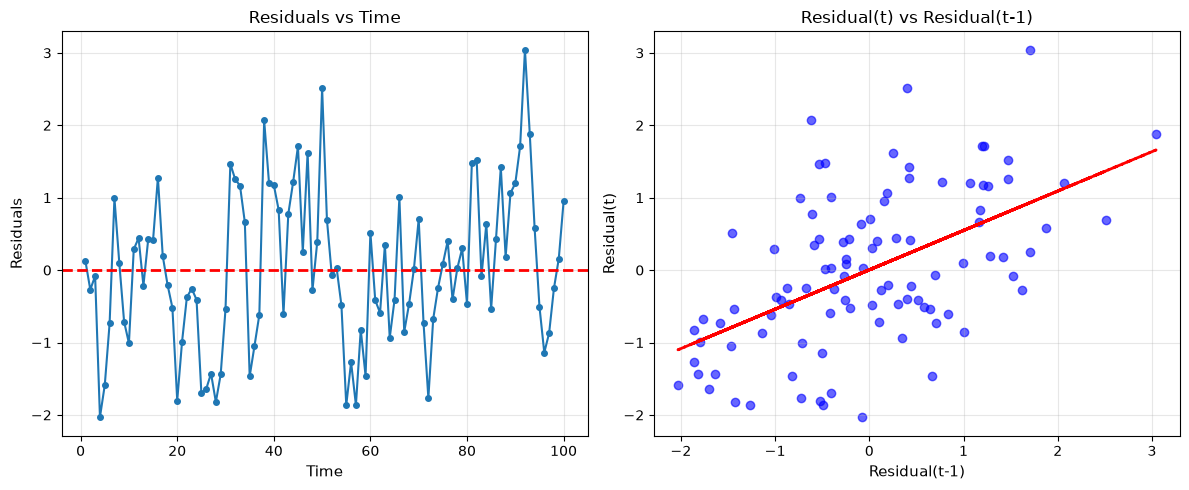

In [59]:
# ============================================================
# STEP 3: Visualize Autocorrelation
# ============================================================
# Plot 1: Residuals vs Time
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(df['time'], residuals, marker='o', linestyle='-', markersize=4)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Time', fontsize=11)
plt.ylabel('Residuals', fontsize=11)
plt.title('Residuals vs Time', fontsize=12)
plt.grid(True, alpha=0.3)

# Plot 2: Residuals vs Lagged Residuals
plt.subplot(1, 2, 2)
plt.scatter(residuals[:-1], residuals[1:], alpha=0.6, color='blue')
plt.xlabel('Residual(t-1)', fontsize=11)
plt.ylabel('Residual(t)', fontsize=11)
plt.title('Residual(t) vs Residual(t-1)', fontsize=12)
plt.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(residuals[:-1], residuals[1:], 1)
p = np.poly1d(z)
plt.plot(residuals[:-1], p(residuals[:-1]), "r--", linewidth=2)

plt.tight_layout()
plt.show()

# Interpretation:
# - Pattern in residuals vs time indicates autocorrelation
# - Positive slope in lag plot indicates positive autocorrelation


In [60]:
# ============================================================
# STEP 4: Durbin-Watson Test
# ============================================================
# The Durbin-Watson test detects first-order autocorrelation
# Test statistic ranges from 0 to 4:
#   - DW ≈ 2: No autocorrelation
#   - DW < 2: Positive autocorrelation
#   - DW > 2: Negative autocorrelation

dw_statistic = durbin_watson(residuals)

print("="*70)
print("DURBIN-WATSON TEST FOR AUTOCORRELATION")
print("="*70)
print(f"\nDurbin-Watson Statistic: {dw_statistic:.4f}")

print(f"\n{'='*70}")
print("INTERPRETATION:")
print(f"{'='*70}")
if dw_statistic < 1.5:
    print("✓ POSITIVE AUTOCORRELATION DETECTED")
    print("  → DW statistic significantly less than 2")
    print("  → Residuals are positively correlated")
elif dw_statistic > 2.5:
    print("✓ NEGATIVE AUTOCORRELATION DETECTED")
    print("  → DW statistic significantly greater than 2")
    print("  → Residuals are negatively correlated")
else:
    print("✗ No evidence of autocorrelation")
    print("  → DW statistic close to 2")
print(f"{'='*70}")


DURBIN-WATSON TEST FOR AUTOCORRELATION

Durbin-Watson Statistic: 0.9129

INTERPRETATION:
✓ POSITIVE AUTOCORRELATION DETECTED
  → DW statistic significantly less than 2
  → Residuals are positively correlated


<Figure size 1000x600 with 0 Axes>

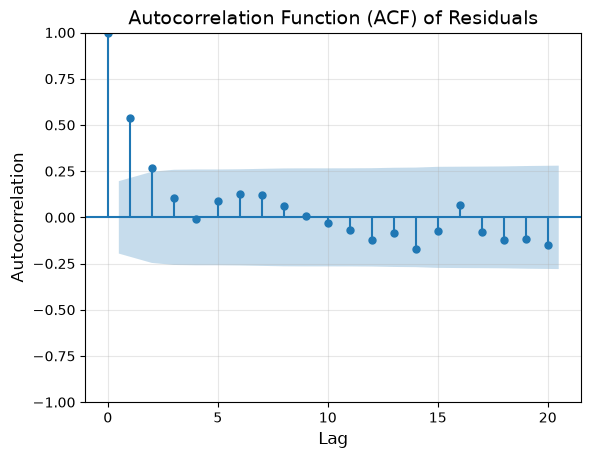

In [61]:
# ============================================================
# STEP 5: Autocorrelation Function (ACF) Plot
# ============================================================
from statsmodels.graphics.tsaplots import plot_acf

# Create ACF plot
plt.figure(figsize=(10, 6))
plot_acf(residuals, lags=20, alpha=0.05)
plt.title('Autocorrelation Function (ACF) of Residuals', fontsize=14)
plt.xlabel('Lag', fontsize=12)
plt.ylabel('Autocorrelation', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# Interpretation:
# - Bars outside confidence interval (blue shaded area) indicate significant autocorrelation
# - Gradual decay suggests positive autocorrelation


In [62]:
# ============================================================
# STEP 6: Solution 1 - Add Lagged Variables
# ============================================================
# Create lagged variables
df['y_lag1'] = df['y'].shift(1)  # Lag 1
df['x_lag1'] = df['x'].shift(1)  # Lag 1

# Remove rows with NaN values (first row)
df_lagged = df.dropna()

# Fit model with lagged dependent variable
x_lagged = sm.add_constant(df_lagged[['x', 'y_lag1']])
model_lagged = sm.OLS(df_lagged['y'], x_lagged).fit()

# Get residuals from lagged model
residuals_lagged = model_lagged.resid

# Test for autocorrelation in new model
dw_statistic_lagged = durbin_watson(residuals_lagged)

print(f"\nAfter Adding Lagged Variable:")
print(f"  Durbin-Watson Statistic: {dw_statistic_lagged:.4f}")
print(f"  {'Autocorrelation REDUCED!' if abs(dw_statistic_lagged - 2) < abs(dw_statistic - 2) else 'Still present'}")


After Adding Lagged Variable:
  Durbin-Watson Statistic: 0.8777
  Still present


In [63]:
# ============================================================
# STEP 7: Solution 2 - Differencing
# ============================================================
# First-order differencing: Δy_t = y_t - y_(t-1)
df['y_diff'] = df['y'].diff()
df['x_diff'] = df['x'].diff()

# Remove NaN values
df_diff = df.dropna()

# Fit model on differenced data
x_diff = sm.add_constant(df_diff['x_diff'])
model_diff = sm.OLS(df_diff['y_diff'], x_diff).fit()

# Get residuals
residuals_diff = model_diff.resid

# Test for autocorrelation
dw_statistic_diff = durbin_watson(residuals_diff)

print(f"\nAfter Differencing:")
print(f"  Durbin-Watson Statistic: {dw_statistic_diff:.4f}")
print(f"  {'Autocorrelation FIXED!' if 1.5 < dw_statistic_diff < 2.5 else 'Still present'}")



After Differencing:
  Durbin-Watson Statistic: 2.3930
  Autocorrelation FIXED!


In [64]:
# ============================================================
# STEP 8: Solution 3 - Robust Standard Errors (Newey-West)
# ============================================================
# Newey-West standard errors are robust to both
# heteroscedasticity and autocorrelation
# # without changing the regression coefficients.

# Fit original model with Newey-West standard errors
# maxlags=1 specifies the number of lags to use
model_robust = model.get_robustcov_results(
    cov_type="HAC",
    maxlags=1
)

# Compare standard errors
print("\n" + "="*70)
print("STANDARD ERRORS COMPARISON")
print("="*70)
print(f"\n{'Coefficient':<15} {'OLS SE':<20} {'Newey-West SE':<20}")
print("-"*70)

# ------------------------------------------------------------
# Convert everything to NumPy arrays
# ------------------------------------------------------------

coef_names = model.params.index
ols_se = np.asarray(model.bse)
nw_se = np.asarray(model_robust.bse)

# ------------------------------------------------------------
# Print comparison table
# ------------------------------------------------------------

for name, ols, nw in zip(coef_names, ols_se, nw_se):
    print(f"{name:<15}{ols:<15.4f}{nw:<20.4f}")

print("="*70)
print("Note: Newey-West SEs are typically larger when autocorrelation exists")
print("="*70)


STANDARD ERRORS COMPARISON

Coefficient     OLS SE               Newey-West SE       
----------------------------------------------------------------------
const          0.2012         0.1998              
x              0.0362         0.0319              
Note: Newey-West SEs are typically larger when autocorrelation exists


In [66]:
# ============================================================
# STEP 9: Compare Model Results
# ============================================================
print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(f"\n{'Model':<25} {'DW Statistic':<15} {'R-squared':<15}")
print("-"*70)
print(f"{'Original OLS':<25} {dw_statistic:<15.4f} {model.rsquared:<15.4f}")
print(f"{'With Lagged Variable':<25} {dw_statistic_lagged:<15.4f} {model_lagged.rsquared:<15.4f}")
print(f"{'Differenced Model':<25} {dw_statistic_diff:<15.4f} {model_diff.rsquared:<15.4f}")
print("="*70)


MODEL COMPARISON

Model                     DW Statistic    R-squared      
----------------------------------------------------------------------
Original OLS              0.9129          0.9692         
With Lagged Variable      0.8777          0.9697         
Differenced Model         2.3930          0.9849         


**Key Takeaways:**
1. Plot residuals vs time to detect autocorrelation visually
2. Durbin-Watson test formally tests for first-order autocorrelation
3. ACF plot shows autocorrelation at different lags
4. Adding lagged variables can account for autocorrelation
5. Differencing removes trends and autocorrelation
6. Newey-West standard errors provide valid inference
7. Time series models (ARIMA) are designed for autocorrelated data


```mermaid
graph LR
    A[Time Series Data] --> B[Fit OLS Model]
    B --> C[Calculate Residuals]
    C --> D[DW Test]
    
    D -->|DW ≈ 2| E[No Autocorrelation]
    D -->|DW < 2| F[Positive Autocorrelation]
    D -->|DW > 2| G[Negative Autocorrelation]
    
    F --> H{Choose Solution}
    G --> H
    
    H --> I[Add Lagged Variables]
    H --> J[First Differencing]
    H --> K[Newey-West SE]
    H --> L[ARIMA Model]
    
    I --> M[Re-test DW]
    J --> M
    K --> N[Valid Inference]
    L --> N
    
    M -->|DW ≈ 2| E
    M -->|Still autocorrelated| H
```

---

## 5. No Multicollinearity

This is an assumption about the relationships *among* the independent variables.

**What is Multicollinearity?**

Multicollinearity occurs when two or more independent variables in a regression model are highly correlated with each other. This makes it difficult to isolate the individual effect of each variable.

**Types:**
- **Perfect multicollinearity**: One variable is a perfect linear combination of others
- **High multicollinearity**: Variables are highly but not perfectly correlated

**What Happens When This Assumption is Violated?**
- **Unstable Estimates:** The coefficient estimates become very sensitive to small changes in the data.
- **Large Standard Errors:** High multicollinearity inflates the standard errors of the coefficients, making them less likely to be statistically significant.
- **Difficulty Interpreting Coefficients:** It's hard to determine which variable is truly driving the effect because they move together.
- Coefficients remain unbiased but have high variance. Coefficients become unstable and sensitive to small changes
- t-statistics become small (variables appear insignificant)

**How to Check This Assumption**
1.  **Correlation Matrix:** Look at pairwise correlations between predictors. A correlation coefficient above `0.8` or `0.9` is a strong indicator.
2.  **Variance Inflation Factor (VIF):** This is the best metric. VIF measures how much the variance of a coefficient is inflated due to collinearity with other predictors.

**What to Do When the Assumption Fails?**
- **Remove Redundant Variables:** If two variables are highly correlated, drop one of them.
- **Combine Variables:** Use techniques like Principal Component Analysis (PCA) to create a new, uncorrelated set of features.
- **Increase Sample Size:** Sometimes, having more data can help mitigate the issue.
- **Use Regularization:** Methods like Ridge and Lasso regression are designed to handle multicollinearity by shrinking the coefficients.



### 📊 Visual Diagram

```mermaid
graph TD
    A[Multiple Independent Variables] --> B[Check Correlations]
    B --> C{High Correlation?}
    
    C -->|No| D[No Multicollinearity ✓]
    C -->|Yes| E[Multicollinearity ✗]
    
    E --> F[Calculate VIF]
    F --> G{VIF > 10?}
    
    G -->|No| H[Acceptable]
    G -->|Yes| I[Severe Multicollinearity]
    
    I --> J[Solutions]
    J --> K[Remove Variable]
    J --> L[Combine Variables]
    J --> M[PCA/Dimensionality Reduction]
    J --> N[Ridge Regression]
```


In [67]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# ============================================================
# STEP 1: Generate data with multicollinearity
# ============================================================
np.random.seed(42)
n_samples = 100

# Generate correlated independent variables
# X1 and X2 are highly correlated (multicollinearity)
X1 = np.random.rand(n_samples) * 10
X2 = 0.9 * X1 + np.random.normal(0, 1, n_samples)  # High correlation with X1
X3 = np.random.rand(n_samples) * 10  # Independent variable

# Create dependent variable
y = 3 * X1 + 2 * X2 + 1.5 * X3 + np.random.normal(0, 2, n_samples)

# Create DataFrame
df = pd.DataFrame({
    'X1': X1,
    'X2': X2,
    'X3': X3,
    'y': y
})

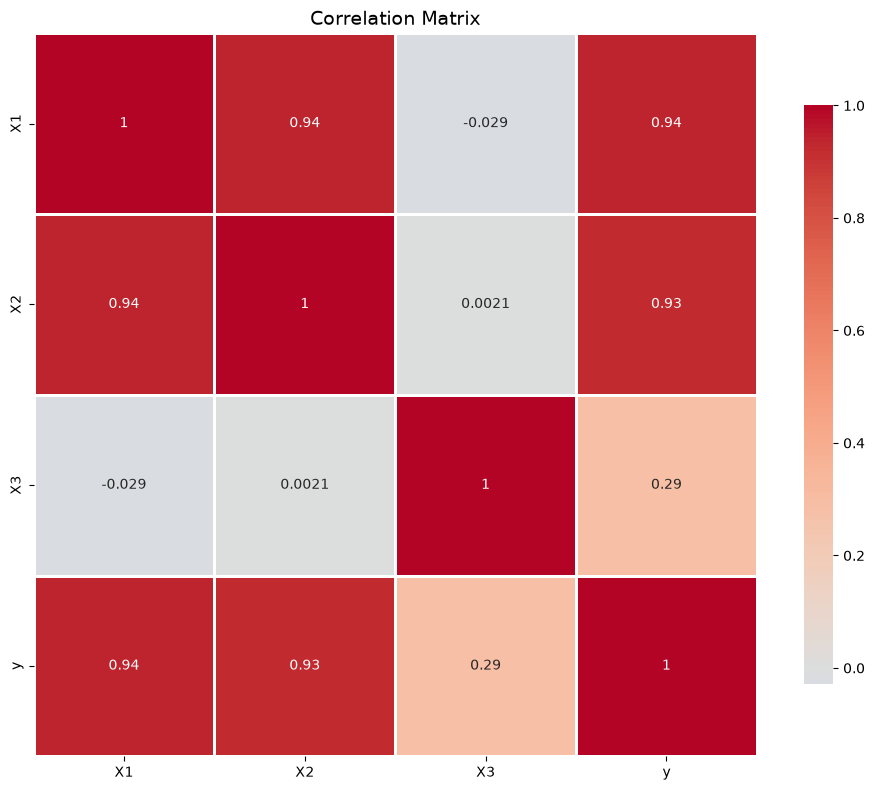

CORRELATION MATRIX
          X1        X2        X3         y
X1  1.000000  0.942298 -0.028591  0.936821
X2  0.942298  1.000000  0.002140  0.925343
X3 -0.028591  0.002140  1.000000  0.286235
y   0.936821  0.925343  0.286235  1.000000


In [68]:
# ============================================================
# STEP 2: Visualize Correlations
# ============================================================
# Create correlation matrix
corr_matrix = df.corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

# Interpretation:
# - High correlation between X1 and X2 indicates multicollinearity
# - Correlation > 0.8 is typically concerning

print("="*70)
print("CORRELATION MATRIX")
print("="*70)
print(corr_matrix)
print("="*70)


In [69]:
# ============================================================
# STEP 3: Variance Inflation Factor (VIF)
# ============================================================
# VIF measures how much the variance of a coefficient is inflated
# due to multicollinearity
# 
# VIF Formula: VIF_i = 1 / (1 - R²_i)
# where R²_i is the R-squared from regressing X_i on other X's
#
# Interpretation:
#   VIF = 1: No multicollinearity
#   1 < VIF < 5: Moderate multicollinearity
#   VIF > 5 or 10: Severe multicollinearity

# Prepare data for VIF calculation
X = df[['X1', 'X2', 'X3']]
X_with_const = sm.add_constant(X)

# Calculate VIF for each variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\n" + "="*70)
print("VARIANCE INFLATION FACTOR (VIF)")
print("="*70)
print(vif_data)
print("="*70)

# Interpretation guide
print("\nVIF INTERPRETATION:")
print("-" * 70)
for _, row in vif_data.iterrows():
    var = row['Variable']
    vif = row['VIF']
    
    if vif < 5:
        print(f"{var:10s}: VIF = {vif:.2f} → Acceptable")
    elif vif < 10:
        print(f"{var:10s}: VIF = {vif:.2f} → Moderate multicollinearity")
    else:
        print(f"{var:10s}: VIF = {vif:.2f} → SEVERE multicollinearity!")
print("-" * 70)



VARIANCE INFLATION FACTOR (VIF)
  Variable        VIF
0       X1  30.688271
1       X2  31.323536
2       X3   2.238342

VIF INTERPRETATION:
----------------------------------------------------------------------
X1        : VIF = 30.69 → SEVERE multicollinearity!
X2        : VIF = 31.32 → SEVERE multicollinearity!
X3        : VIF = 2.24 → Acceptable
----------------------------------------------------------------------


In [ ]:
# ============================================================
# STEP 4: Fit OLS Model (with multicollinearity)
# ============================================================
# Add constant term
X_with_const = sm.add_constant(X)

# Fit OLS model
model_ols = sm.OLS(y, X_with_const).fit()

# Display model summary
print("\n" + "="*70)
print("OLS MODEL SUMMARY (With Multicollinearity)")
print("="*70)
print(model_ols.summary())
print("="*70)

# Key observations:
# - High R-squared but insignificant individual variables
# - Large standard errors
# - Coefficients may have unexpected signs


OLS MODEL SUMMARY (With Multicollinearity)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     2216.
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           1.80e-88
Time:                        15:32:18   Log-Likelihood:                -198.15
No. Observations:                 100   AIC:                             404.3
Df Residuals:                      96   BIC:                             414.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const   

In [71]:
# ============================================================
# STEP 5: Solution 1 - Remove One Correlated Variable
# ============================================================
# Remove X2 (highly correlated with X1)
X_reduced = df[['X1', 'X3']]
X_reduced_const = sm.add_constant(X_reduced)

# Fit model with reduced variables
model_reduced = sm.OLS(y, X_reduced_const).fit()

# Calculate VIF for reduced model
vif_reduced = pd.DataFrame()
vif_reduced["Variable"] = X_reduced.columns
vif_reduced["VIF"] = [variance_inflation_factor(X_reduced.values, i) for i in range(X_reduced.shape[1])]

print("\n" + "="*70)
print("AFTER REMOVING X2")
print("="*70)
print("\nVIF Values:")
print(vif_reduced)

print("\nModel Summary:")
print(model_reduced.summary())
print("="*70)



AFTER REMOVING X2

VIF Values:
  Variable     VIF
0       X1  2.1876
1       X3  2.1876

Model Summary:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     1947.
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           5.09e-79
Time:                        15:32:51   Log-Likelihood:                -224.90
No. Observations:                 100   AIC:                             455.8
Df Residuals:                      97   BIC:                             463.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------

In [72]:
# ============================================================
# STEP 6: Solution 2 - Combine Variables (Create Index)
# ============================================================
# Create a combined variable (e.g., average of X1 and X2)
df['X1_X2_combined'] = (df['X1'] + df['X2']) / 2

# Use combined variable instead of X1 and X2
X_combined = df[['X1_X2_combined', 'X3']]
X_combined_const = sm.add_constant(X_combined)

# Fit model with combined variable
model_combined = sm.OLS(y, X_combined_const).fit()

# Calculate VIF
vif_combined = pd.DataFrame()
vif_combined["Variable"] = X_combined.columns
vif_combined["VIF"] = [variance_inflation_factor(X_combined.values, i) for i in range(X_combined.shape[1])]

print("\n" + "="*70)
print("AFTER COMBINING X1 AND X2")
print("="*70)
print("\nVIF Values:")
print(vif_combined)

print("\nModel Summary:")
print(model_combined.summary())
print("="*70)



AFTER COMBINING X1 AND X2

VIF Values:
         Variable       VIF
0  X1_X2_combined  2.231123
1              X3  2.231123

Model Summary:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     2796.
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           1.74e-86
Time:                        15:33:05   Log-Likelihood:                -207.18
No. Observations:                 100   AIC:                             420.4
Df Residuals:                      97   BIC:                             428.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025

In [73]:
# ============================================================
# STEP 7: Solution 3 - Ridge Regression
# ============================================================
# Ridge regression adds L2 penalty to handle multicollinearity
# It shrinks coefficients but doesn't eliminate variables

from sklearn.preprocessing import StandardScaler

# Standardize features (important for Ridge)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Try different alpha values (regularization strength)
alphas = [0.01, 0.1, 1, 10, 100]

print("\n" + "="*70)
print("RIDGE REGRESSION WITH DIFFERENT ALPHA VALUES")
print("="*70)
print(f"\n{'Alpha':<10} {'X1 Coef':<15} {'X2 Coef':<15} {'X3 Coef':<15}")
print("-"*70)

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_scaled, y)
    
    print(f"{alpha:<10.2f} {ridge.coef_[0]:<15.4f} {ridge.coef_[1]:<15.4f} {ridge.coef_[2]:<15.4f}")

print("="*70)
print("Note: As alpha increases, coefficients shrink toward zero")
print("="*70)



RIDGE REGRESSION WITH DIFFERENT ALPHA VALUES

Alpha      X1 Coef         X2 Coef         X3 Coef        
----------------------------------------------------------------------
0.01       9.7333          4.4308          4.4791         
0.10       9.6879          4.4696          4.4737         
1.00       9.2963          4.7952          4.4220         
10.00      7.6592          5.8060          4.0157         
100.00     4.7763          4.5536          2.1688         
Note: As alpha increases, coefficients shrink toward zero


In [74]:
# ============================================================
# STEP 8: Solution 4 - Principal Component Analysis (PCA)
# ============================================================
from sklearn.decomposition import PCA

# Standardize features
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)  # Reduce to 2 components
X_pca = pca.fit_transform(X_scaled)

# Create DataFrame with principal components
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca_const = sm.add_constant(df_pca)

# Fit model with principal components
model_pca = sm.OLS(y, df_pca_const).fit()

# Display explained variance
print("\n" + "="*70)
print("PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("="*70)
print(f"\nExplained Variance Ratio:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)")
print(f"  Total: {sum(pca.explained_variance_ratio_):.4f} ({sum(pca.explained_variance_ratio_)*100:.2f}%)")

print("\nModel Summary with PCA:")
print(model_pca.summary())
print("="*70)


PRINCIPAL COMPONENT ANALYSIS (PCA)

Explained Variance Ratio:
  PC1: 0.6476 (64.76%)
  PC2: 0.3334 (33.34%)
  Total: 0.9809 (98.09%)

Model Summary with PCA:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     2620.
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           3.83e-85
Time:                        15:33:36   Log-Likelihood:                -210.36
No. Observations:                 100   AIC:                             426.7
Df Residuals:                      97   BIC:                             434.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>

In [75]:
# ============================================================
# STEP 9: Compare All Solutions
# ============================================================
print("\n" + "="*70)
print("COMPARISON OF ALL MODELS")
print("="*70)
print(f"\n{'Model':<25} {'R-squared':<15} {'Max VIF':<15}")
print("-"*70)

# Original model (with multicollinearity)
print(f"{'Original OLS':<25} {model_ols.rsquared:<15.4f} {vif_data['VIF'].max():<15.2f}")

# Reduced model
print(f"{'Remove Variable':<25} {model_reduced.rsquared:<15.4f} {vif_reduced['VIF'].max():<15.2f}")

# Combined model
print(f"{'Combine Variables':<25} {model_combined.rsquared:<15.4f} {vif_combined['VIF'].max():<15.2f}")

# PCA model (VIF not applicable for PCs)
print(f"{'PCA':<25} {model_pca.rsquared:<15.4f} {'N/A':<15}")

print("="*70)


COMPARISON OF ALL MODELS

Model                     R-squared       Max VIF        
----------------------------------------------------------------------
Original OLS              0.9858          31.32          
Remove Variable           0.9757          2.19           
Combine Variables         0.9829          2.23           
PCA                       0.9818          N/A            


**Key Takeaways:**
1. Correlation matrix reveals pairwise correlations
2. VIF > 5 or 10 indicates severe multicollinearity
3. Remove one of the highly correlated variables
4. Combine correlated variables into an index
5. Use Ridge Regression to shrink coefficients
6. Apply PCA to create uncorrelated components
7. Collect more data if possible


```mermaid
sequenceDiagram
    participant Data as Original Data
    participant Check as Check Linearity
    participant Transform as Apply Transformation
    participant Poly as Polynomial Regression
    participant Model as Final Model
    
    Data->>Check: Scatter Plot & Residual Plot
    Check->>Check: Detect Pattern?
    alt Pattern Detected (Non-linear)
        Check->>Transform: Try sqrt/log transform
        Transform->>Model: Check improved linearity
        alt Still Non-linear
            Check->>Poly: Add polynomial terms
            Poly->>Model: degree=2, 3, etc.
        end
    else No Pattern (Linear)
        Check->>Model: Use linear model
    end
    Model->>Model: Validate assumptions
```

---

## 📝 Summary Table

| Assumption | What It Means | How to Check | What to Do if Violated |
|------------|---------------|--------------|------------------------|
| **Linearity** | Linear relationship between X and Y | Scatter plots, Residual plots | Transformations, Polynomial regression, GAM |
| **Normality** | Residuals follow normal distribution | Histogram, Q-Q plot, Shapiro-Wilk test | Transform Y, Robust regression, Bootstrapping |
| **Homoscedasticity** | Constant variance of residuals | Residual plot, Breusch-Pagan test | Transform variables, WLS, Robust SE |
| **No Autocorrelation** | Residuals are independent | Residual vs time plot, Durbin-Watson test | Add lags, Differencing, Newey-West SE, ARIMA |
| **No Multicollinearity** | Independent variables not correlated | Correlation matrix, VIF | Remove variables, Combine, Ridge, PCA |

---

## 🎯 Best Practices

1. **Always check assumptions** before interpreting results
2. **Visual inspection** is as important as statistical tests
3. **Multiple methods** should be used to verify each assumption
4. **Document violations** and the steps taken to address them
5. **Consider sample size** - some assumptions relax with large samples
6. **Domain knowledge** helps in choosing appropriate transformations
7. **Iterate** - fixing one assumption may affect others

---

## 📚 Additional Resources

- **Books**: 
  - "Applied Linear Statistical Models" by Kutner et al.
  - "Introduction to Linear Regression Analysis" by Montgomery et al.

- **Python Libraries**:
  - `statsmodels` - Comprehensive statistical tests
  - `scikit-learn` - Machine learning implementations
  - `seaborn` - Advanced visualizations

- **Online Resources**:
  - StatLect: https://www.statlect.com/
  - Towards Data Science: https://towardsdatascience.com/

---


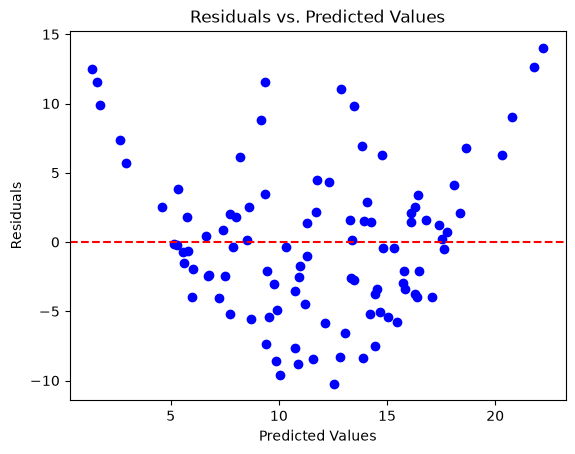

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. GENERATING SYNTHETIC DATA
# We generate random features x1 and x2, and a target y that has a built-in 
# non-linear relationship (x**2 + y**2) and interaction term (0.1*x*y)
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8
z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y + 2 + np.random.randn(100, 1)

df = pd.DataFrame()
df['x1'] = x.reshape(100)
df['x2'] = y.reshape(100)
df['y'] = z.reshape(100)

# 2. FITTING THE NAIVE LINEAR MODEL
X = df[['x1', 'x2']]
target = df['y']

model = LinearRegression()
model.fit(X, target)

# 3. CALCULATING RESIDUALS
# Residuals = Actual y - Predicted y. They represent the error of the model.
y_pred = model.predict(X)
residuals = target - y_pred

# 4. DIAGNOSTIC PLOTTING (Residual Plot)
# A healthy residual plot should look like a random cloud of points scattered 
# evenly around the zero line. If a pattern exists (like a U-shape or funnel), 
# the linearity or homoscedasticity assumptions are violated.
plt.scatter(y_pred, residuals, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

In [77]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, target, test_size=0.2, random_state=42)

# 1. EVALUATING THE FAILED LINEAR MODEL
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_y_pred = linear_model.predict(X_test)

# Metrics show poor performance due to assumption violation
linear_r2 = r2_score(y_test, linear_y_pred)
linear_mse = mean_squared_error(y_test, linear_y_pred)

# 2. APPLYING POLYNOMIAL FEATURES
# This transforms our features [x1, x2] into [1, x1, x2, x1^2, x1*x2, x2^2]
poly_features = PolynomialFeatures(degree=2)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

# We fit the same LinearRegression algorithm, but on the new polynomial feature space
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
poly_y_pred = poly_model.predict(X_test_poly)

# Metrics dramatically improve, confirming the non-linear structure was captured
poly_r2 = r2_score(y_test, poly_y_pred)
poly_mse = mean_squared_error(y_test, poly_y_pred)

print(f"Linear R-squared: {linear_r2:.4f} | MSE: {linear_mse:.4f}")
print(f"Polynomial R-squared: {poly_r2:.4f} | MSE: {poly_mse:.4f}")

Linear R-squared: 0.0736 | MSE: 32.5552
Polynomial R-squared: 0.9626 | MSE: 1.3144


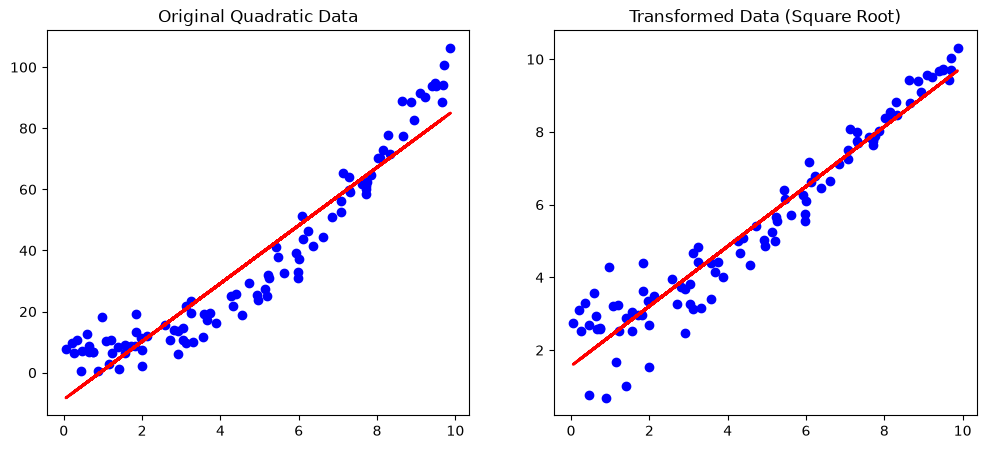

Original R-squared: 0.9008
Transformed R-squared: 0.9291


In [78]:
# Generate a new non-linear dataset with a quadratic relationship
np.random.seed(42)
x_val = 10 * np.random.rand(100, 1)
# The true relationship is quadratic with added noise
y_val = x_val**2 + 5 + np.random.normal(0, 5, (100, 1))
y_val = np.abs(y_val)  # Ensure non-negative for the square root transform

# 1. APPLYING THE SQUARE ROOT TRANSFORMATION
# Transforming the dependent variable condenses large values, making the 
# exponential relationship more linear.
y_sqrt = np.sqrt(y_val)

# 2. FIT MODELS FOR COMPARISON
# Original Data Fit
linear_model_original = LinearRegression()
linear_model_original.fit(x_val, y_val)
y_pred_original = linear_model_original.predict(x_val)

# Transformed Data Fit
linear_model_transformed = LinearRegression()
linear_model_transformed.fit(x_val, y_sqrt)
y_pred_transformed = linear_model_transformed.predict(x_val)

# 3. VISUALIZING THE FIX
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Notice how the red regression line fails to capture the curve
ax1.scatter(x_val, y_val, color='blue')
ax1.plot(x_val, y_pred_original, color='red', linewidth=2)
ax1.set_title('Original Quadratic Data')

# Plot 2: The transformation straightens the data, making the linear fit accurate
ax2.scatter(x_val, y_sqrt, color='blue')
ax2.plot(x_val, y_pred_transformed, color='red', linewidth=2)
ax2.set_title('Transformed Data (Square Root)')

plt.show()

# Performance comparison
print(f"Original R-squared: {r2_score(y_val, y_pred_original):.4f}")
print(f"Transformed R-squared: {r2_score(y_sqrt, y_pred_transformed):.4f}")